# 04 — Building a Text-to-Text Generation System with Transformers

## 📚 Learning Objectives

By completing this notebook, you will:
- Build an **encoder–decoder Transformer** (the T5/BART architecture family) in pure PyTorch
- Understand the seq2seq machinery: SOS/EOS tokens, teacher forcing, the causal target mask, greedy decoding
- Learn why Transformers need **positional encodings** — attention alone is order-blind
- **Evaluate** the system with exact-match and per-character accuracy on held-out *real* sentences, and read the errors it actually makes

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lessons 01 and 04 (attention, and seq2seq with an encoder-decoder) — that architecture, now built and trained in PyTorch by the usual recipe: define a loss, then use gradient descent to nudge the parameters.

**Used later in:** Course 10 — Unit 3, lesson 04, where the same conditioning idea plugs text into an image generator.

## 📊 Data used in this notebook

**Real published prose** from the NLTK Gutenberg corpus — six books (Carroll, Austen ×2, Chesterton ×2, Bryant). Every training pair is built from a real sentence:

| side | content |
|---|---|
| **source** | the sentence stripped to lowercase letters and spaces — `so goodby my dear` |
| **target** | the sentence exactly as the author wrote it — `So goodby, my dear.` |

Nothing here is invented: the target is the author's real text, and the source is that same real text with information deliberately removed.

---

## Introduction

**Text-to-text** systems (T5, BART, translation models) frame every task as "text in → text out": an **encoder** reads the input sequence, a **decoder** generates the output autoregressively while attending to the encoder's states.

Our task is **truecasing and punctuation restoration** — turning `i ought to travel` back into `I ought to travel.` This is not a puzzle invented for a notebook: it is a standard production stage in **speech-recognition pipelines**, which emit an unpunctuated lowercase token stream that has to be made readable before a human sees it. Subtitles, voice notes, and meeting transcripts all run a model like this one.

Because the data is real, the task is genuinely **partly ambiguous** — nothing in the stripped string `it will be giving him so much pleasure` tells you that Austen ended it with `!` rather than `.`. Expect held-out exact-match accuracy well below 100% (we measure **49.0%**, against **81.6%** per-character), and read the failures: they are where the lesson is.

**One detail is load-bearing: positional encodings.** Self-attention is *permutation-invariant* — without position information the model cannot represent "first character" vs "last character", so it could not learn to capitalise the *opening* letter or place a mark at the *end*. Our model adds a learned positional embedding to every token. The **ablation cell below** removes them and measures what happens: exact-match accuracy falls from **49.0% to 0.5%**, and per-character accuracy from **81.6% to 14.4%**, on the same 200 held-out sentences.

---

## 🌍 Why this lesson exists — a production stage that got deleted

Truecasing and punctuation restoration — the task you are about to build — was a standard, separately-trained stage in every speech-recognition pipeline for years: the recogniser emitted an unbroken lowercase token stream, and this component made it readable before a human saw it. Then OpenAI's **Whisper** (Radford et al., 2022) shipped a model that emits cased, punctuated text directly, and for most pipelines the separate restoration model simply stopped being built.

Both halves of that are worth carrying: the task is genuinely a production stage (subtitles, voice notes, meeting transcripts all depend on it), *and* a well-defined component can be absorbed by a larger end-to-end model in a single release. Knowing which of your components is absorbable is a career skill.

**What goes wrong without this:** without a restoration stage, an ASR system hands a human an unreadable lowercase wall. The task exists only because the information was stripped upstream — which is also why parts of it are unrecoverable, as the results below show.


In [1]:
# WHAT/WHY: build and train a small encoder-decoder Transformer that restores
# capitalisation and punctuation to REAL sentences from published books, then
# measure exact-match and per-character accuracy on held-out sentences.
# Note the positional embeddings — without them, attention cannot see token
# order, and "capitalise the first letter / punctuate the last" is unlearnable.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import numpy as np
import re
print(f'PyTorch {torch.__version__}')

torch.manual_seed(0); np.random.seed(0)

# ── REAL DATA: six books from the NLTK Gutenberg corpus ───────────────────
# Fallback keeps the notebook runnable offline; both branches are real text.
def load_books():
    try:
        import nltk
        nltk.download('gutenberg', quiet=True)
        from nltk.corpus import gutenberg
        books = ['carroll-alice.txt', 'austen-emma.txt', 'chesterton-brown.txt',
                 'bryant-stories.txt', 'austen-sense.txt', 'chesterton-thursday.txt']
        return [(b, gutenberg.raw(b)) for b in books]
    except Exception:
        from sklearn.datasets import fetch_20newsgroups
        news = fetch_20newsgroups(subset='train', categories=['rec.autos'],
                                  remove=('headers', 'footers', 'quotes'))
        return [('20newsgroups rec.autos (fallback)', " ".join(news.data))]

# ── Build (stripped sentence → original sentence) pairs ───────────────────
# The TARGET is the author's real sentence. The SOURCE is that same sentence
# with case and punctuation removed - exactly what a speech recogniser emits.
pairs = []
for name, raw in load_books():
    raw = re.sub(r'\s+', ' ', raw)
    for s in re.split(r'(?<=[.!?]) ', raw):
        s = s.strip()
        if not (12 <= len(s) <= 40):                       # keep sentences short
            continue
        if not re.fullmatch(r"[A-Za-z ,.'!?]+", s):        # plain prose only
            continue
        src = re.sub(r'\s+', ' ', re.sub(r"[^a-z ]", '', s.lower())).strip()
        if len(src) >= 8:
            pairs.append((src, s))

print(f'Real sentence pairs extracted: {len(pairs):,}')
print('Examples (source → target):')
for a, b in pairs[:4]:
    print(f'  {a!r} → {b!r}')

# ── Character vocabulary over both sides + 3 special tokens ───────────────
chars = sorted(set(''.join(a for a, _ in pairs) + ''.join(b for _, b in pairs)))
c2i = {c: i for i, c in enumerate(chars)}
i2c = {i: c for c, i in c2i.items()}
PAD, SOS, EOS = len(chars), len(chars) + 1, len(chars) + 2
V = len(chars) + 3
MAX_SRC = max(len(a) for a, _ in pairs)
MAX_TGT = max(len(b) for _, b in pairs)
print(f'\nVocabulary: {V} tokens ({len(chars)} characters + PAD/SOS/EOS)')
print(f'Longest source: {MAX_SRC} chars | longest target: {MAX_TGT} chars')

# ── Held-out split: 90% train / 10% test, shuffled with a fixed seed ──────
rng = np.random.RandomState(0)
pairs = [pairs[i] for i in rng.permutation(len(pairs))]
split = int(0.9 * len(pairs))
train_pairs, test_pairs = pairs[:split], pairs[split:]
print(f'Train: {len(train_pairs):,} sentences | held-out test: {len(test_pairs):,}')

def encode_src(s):
    return [c2i[c] for c in s] + [PAD] * (MAX_SRC - len(s))

def encode_tgt(s):
    # teacher forcing: decoder INPUT starts with SOS, decoder TARGET ends with EOS
    ids = [c2i[c] for c in s]
    return ([SOS] + ids + [PAD] * (MAX_TGT - len(ids)),
            ids + [EOS] + [PAD] * (MAX_TGT - len(ids)))

X_src   = torch.tensor([encode_src(a) for a, _ in train_pairs], dtype=torch.long)
tgt_in  = torch.tensor([encode_tgt(b)[0] for _, b in train_pairs], dtype=torch.long)
tgt_out = torch.tensor([encode_tgt(b)[1] for _, b in train_pairs], dtype=torch.long)
print(f'Tensors — src {tuple(X_src.shape)} | tgt_in {tuple(tgt_in.shape)}')

# ── Encoder-decoder Transformer with LEARNED positional embeddings ────────
class Seq2SeqTransformer(nn.Module):
    def __init__(self, V, d=64, nhead=4, nlayers=2, max_len=64):
        super().__init__()
        self.src_emb = nn.Embedding(V, d)
        self.tgt_emb = nn.Embedding(V, d)
        self.pos_emb = nn.Embedding(max_len, d)   # position i → learned vector
        self.transformer = nn.Transformer(d, nhead, nlayers, nlayers,
                                          dim_feedforward=128, batch_first=True)
        self.fc = nn.Linear(d, V)
    def add_pos(self, emb):
        # add position information — attention alone is order-blind
        pos = torch.arange(emb.size(1), device=emb.device)
        return emb + self.pos_emb(pos)[None, :, :]
    def forward(self, src, tgt):
        # causal mask: decoder position t may only attend to positions ≤ t
        mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1))
        out = self.transformer(self.add_pos(self.src_emb(src)),
                               self.add_pos(self.tgt_emb(tgt)),
                               tgt_mask=mask, tgt_is_causal=True)
        return self.fc(out)

model   = Seq2SeqTransformer(V)
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)

# ── Training with teacher forcing ─────────────────────────────────────────
# Each epoch's mean loss is kept, so the ablation further down can plot this
# run's learning curve against one trained WITHOUT positional embeddings.
loss_hist_pos = []
for epoch in range(20):
    model.train(); el = 0; nb_ = 0
    perm = torch.randperm(len(X_src))
    for i in range(0, len(X_src), 128):
        b = perm[i:i+128]
        logits = model(X_src[b], tgt_in[b])                 # (B, T, V)
        loss   = loss_fn(logits.reshape(-1, V), tgt_out[b].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step(); el += loss.item(); nb_ += 1
    loss_hist_pos.append(el / nb_)
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}: mean batch loss={el/nb_:.4f}')

# ── Greedy decoding: generate the output one character at a time ──────────
def restore(src_text, max_len=None):
    model.eval()
    max_len = max_len or MAX_TGT
    src = torch.tensor([encode_src(src_text)], dtype=torch.long)
    tgt = torch.tensor([[SOS]], dtype=torch.long)          # start with SOS
    for _ in range(max_len):
        with torch.no_grad():
            logits = model(src, tgt)
        nxt = logits[0, -1].argmax().item()                 # most likely next token
        if nxt in (EOS, PAD):
            break                                           # model says it is done
        tgt = torch.cat([tgt, torch.tensor([[nxt]])], dim=1)
    return ''.join(i2c.get(i, '') for i in tgt[0, 1:].tolist())

# ── Evaluation on 200 UNSEEN real sentences ───────────────────────────────
sample = test_pairs[:200]
preds = [restore(a) for a, _ in sample]
exact = sum(p == b for p, (_, b) in zip(preds, sample))
# per-character accuracy: how much of each sentence is right, not just all-or-nothing
char_hits = sum(sum(x == y for x, y in zip(p, b)) for p, (_, b) in zip(preds, sample))
char_tot  = sum(len(b) for _, b in sample)

print('\nHeld-out predictions (source | model | author):')
for (a, b), p in list(zip(sample, preds))[:6]:
    print(f'  {a!r}\n    model : {p!r}\n    author: {b!r}  {"✓" if p == b else "✗"}')
print(f'\nExact-match accuracy on {len(sample)} unseen real sentences: '
      f'{exact}/{len(sample)} = {exact/len(sample):.1%}')
print(f'Per-character accuracy: {char_hits}/{char_tot} = {char_hits/char_tot:.1%}')
print('\nRead the failures before judging the model: most are a missing comma or')
print('a "." where the author wrote "!" — choices no amount of training can')
print('recover from the stripped input, because the information is not there.')


PyTorch 2.13.0


Real sentence pairs extracted: 2,294
Examples (source → target):
  'how brave theyll all think me at home' → "How brave they'll all think me at home!"
  'would the fall never come to an end' → 'Would the fall NEVER come to an end!'
  'dinah my dear' → 'Dinah my dear!'
  'i wish you were down here with me' → 'I wish you were down here with me!'

Vocabulary: 61 tokens (58 characters + PAD/SOS/EOS)
Longest source: 39 chars | longest target: 40 chars
Train: 2,064 sentences | held-out test: 230
Tensors — src (2064, 39) | tgt_in (2064, 41)


Epoch 5: mean batch loss=1.9837


Epoch 10: mean batch loss=0.4739


Epoch 15: mean batch loss=0.2516


Epoch 20: mean batch loss=0.1803



Held-out predictions (source | model | author):
  'i ought to travel'
    model : 'I ought to travel.'
    author: 'I ought to travel.'  ✓
  'so goodby my dear'
    model : 'So goodby My dear.'
    author: 'So goodby, my dear.'  ✗
  'then came an interruption and a change'
    model : 'Then came an interruption and a change.'
    author: 'Then came an interruption and a change.'  ✓
  'it will be giving him so much pleasure'
    model : 'It will be giving him so much pleasure.'
    author: 'It will be giving him so much pleasure!'  ✗
  'i was miserable'
    model : 'I was miserable.'
    author: 'I was miserable.'  ✓
  'here he certainly saved the situation'
    model : 'Here he certainly saved the situation.'
    author: 'Here he certainly saved the situation.'  ✓

Exact-match accuracy on 200 unseen real sentences: 98/200 = 49.0%
Per-character accuracy: 4472/5479 = 81.6%

Read the failures before judging the model: most are a missing comma or
a "." where the author wrote "!" — choices

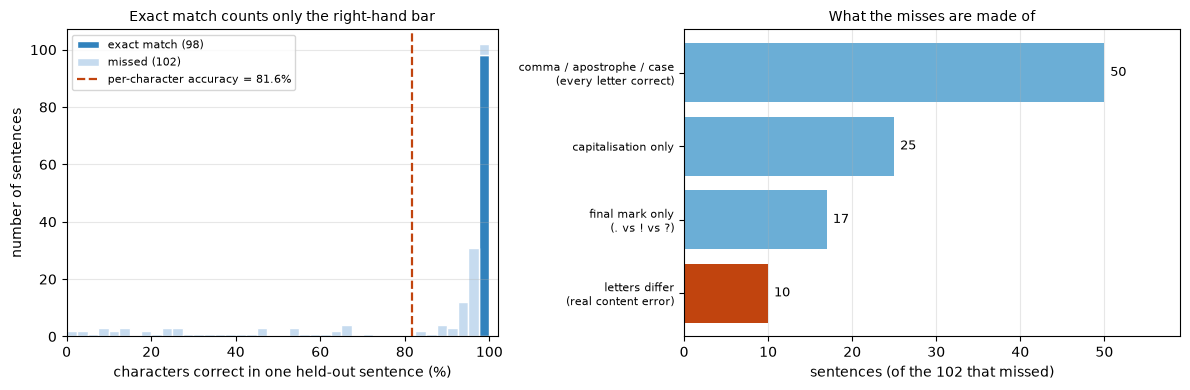

98/200 sentences exact  |  median sentence is 97.5% correct  |  worst is 0.0%
98 sentences reproduce every character of the author's line; 98 of those are byte-identical.
   50  comma / apostrophe / case (every letter correct)
   25  capitalisation only
   17  final mark only (. vs ! vs ?)
   10  letters differ (real content error)

Only 10 of the 102 misses changed a letter; the rest lost exact match on case or a punctuation mark alone.


In [2]:
# WHAT/WHY: 49.0% exact match and 81.6% per-character are two numbers about the
# same 200 sentences, and the distance between them is the lesson. This figure
# opens both up: how close each individual sentence got, and what the failures
# are actually made of. The categories are computed from the predictions above,
# not asserted.
import matplotlib.pyplot as plt

golds = [b for _, b in sample]
per_sentence = np.array([sum(x == y for x, y in zip(p, b)) / len(b)
                         for p, b in zip(preds, golds)])

def category(pred, gold):
    """Classify one mismatch by what actually differs. Order matters: the most
    specific case (only the sentence-final mark) is tested first."""
    letters = lambda s: re.sub(r'[^a-z]', '', s.lower())
    if pred[:-1] == gold[:-1] and pred[-1:] in '.!?' and gold[-1:] in '.!?':
        return 'final mark only\n(. vs ! vs ?)'
    if pred.lower() == gold.lower():
        return 'capitalisation only'
    if letters(pred) == letters(gold):
        return 'comma / apostrophe / case\n(every letter correct)'
    return 'letters differ\n(real content error)'

cats = {}
for p, g in zip(preds, golds):
    if p != g:
        cats[category(p, g)] = cats.get(category(p, g), 0) + 1

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0), gridspec_kw={'width_ratios': [1, 1.15]})

# ── Left: how close did each held-out sentence get? ───────────────────────
exact_mask = np.array([p == g for p, g in zip(preds, golds)])
n_exact = int(exact_mask.sum())
# Stacked, so the last bar shows how many near-perfect sentences still miss.
axes[0].hist([per_sentence[exact_mask] * 100, per_sentence[~exact_mask] * 100],
             bins=np.arange(0, 102.5, 2.5), stacked=True,
             color=['#3182bd', '#c6dbef'], edgecolor='white',
             label=[f'exact match ({n_exact})', f'missed ({len(preds) - n_exact})'])
axes[0].axvline(char_hits / char_tot * 100, color='#c1440e', ls='--', lw=1.6,
                label=f'per-character accuracy = {char_hits / char_tot:.1%}')
axes[0].set_xlabel('characters correct in one held-out sentence (%)')
axes[0].set_ylabel('number of sentences')
axes[0].set_title('Exact match counts only the right-hand bar', fontsize=10)
axes[0].set_xlim(0, 102); axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

# ── Right: what are the misses made of? ───────────────────────────────────
lab = sorted(cats, key=cats.get)
axes[1].barh(range(len(lab)), [cats[k] for k in lab],
             color=['#c1440e' if 'letters differ' in k else '#6baed6' for k in lab])
axes[1].set_yticks(range(len(lab))); axes[1].set_yticklabels(lab, fontsize=8)
for i, k in enumerate(lab):
    axes[1].text(cats[k] + 0.7, i, str(cats[k]), va='center', fontsize=9)
axes[1].set_xlabel(f'sentences (of the {len(preds) - n_exact} that missed)')
axes[1].set_title('What the misses are made of', fontsize=10)
axes[1].set_xlim(0, max(cats.values()) * 1.18); axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

recoverable = cats.get('letters differ\n(real content error)', 0)
print(f'{n_exact}/{len(preds)} sentences exact  |  median sentence is '
      f'{np.median(per_sentence):.1%} correct  |  worst is {per_sentence.min():.1%}')
print(f'{int((per_sentence >= 0.999).sum())} sentences reproduce every character of the '
      f'author\'s line; {n_exact} of those are byte-identical.')
for k in sorted(cats, key=cats.get, reverse=True):
    print(f'  {cats[k]:>3}  {k.replace(chr(10), " ")}')
print(f'\nOnly {recoverable} of the {len(preds) - n_exact} misses changed a letter; the rest lost '
      f'exact match on case or a punctuation mark alone.')


**Read the figure.** Two panels, two halves of one uncomfortable finding.

**Left — the scores describe the same 200 sentences.** Almost every held-out sentence lands in the
right-hand bars: the median sentence is **97.5%** correct, character for character. Exact match
counts only the dark part of the final bar and calls everything else a failure — including the
sentence sitting one comma away from the author's. The dashed line is the 81.6% per-character
figure. Look at the top of the final bar: the dark block is the 98 exact matches, and the pale
sliver sitting on it is sentences that were 97.5–99.9% correct and still scored zero. A thin tail
of genuinely bad outputs runs all the way down to the left, and it is thin.

**Right — the failures are mostly not errors of language.** Of the 102 misses, **only 10 changed a
letter**. The rest lost the whole sentence on a comma, a capital, or a `.` where the author wrote
`!`. That is what makes exact match the wrong headline number for this task: it is measuring the
ambiguity of the input at least as much as the competence of the model. Quote 49.0% to a client
and you understate the system; quote 81.6% and you have to explain that "81.6% correct" still
means half the lines need a human touch. Both numbers are true; neither is sufficient alone.

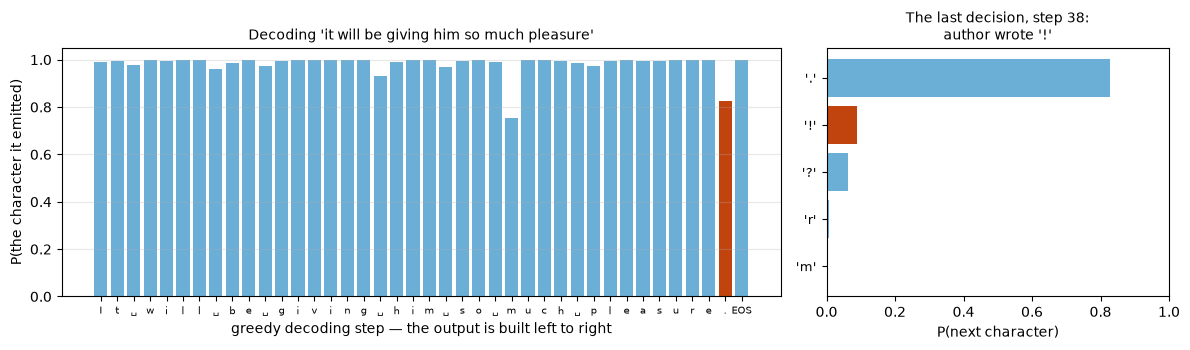

source : 'it will be giving him so much pleasure'
model  : 'It will be giving him so much pleasure.'
author : 'It will be giving him so much pleasure!'

At the final position the model gave '.' p=0.827 and the author's '!' p=0.089.
Lowest confidence anywhere in this decode: 0.754 at step 25 (character 'm').


In [3]:
# STEP_VIZ_COURSE10 — greedy decoding, one character at a time, with the
# model's confidence at every step.
# WHAT/WHY: "greedy decoding cannot repair itself" and "part of this task is
# irreducibly ambiguous" are two claims made in prose above. Both are visible if
# we record the probability of each character as the decoder emits it, on a real
# held-out sentence where the model and the author disagree.

def restore_trace(src_text):
    """Greedy decode, recording the full distribution at every output position."""
    model.eval()
    src = torch.tensor([encode_src(src_text)], dtype=torch.long)
    tgt = torch.tensor([[SOS]], dtype=torch.long)
    trace = []
    for _ in range(MAX_TGT):
        with torch.no_grad():
            logits = model(src, tgt)
        p = torch.softmax(logits[0, -1], 0).numpy()
        nxt = int(p.argmax())                      # greedy: always the maximum
        trace.append((nxt, p))
        if nxt in (EOS, PAD):
            break
        tgt = torch.cat([tgt, torch.tensor([[nxt]])], dim=1)
    return trace

# Pick a real held-out sentence whose ONLY error is the sentence-final mark.
pick = next(((a, g, p) for (a, g), p in zip(sample, preds)
             if p != g and p[:-1] == g[:-1] and p[-1:] in '.!?' and g[-1:] in '.!?'),
            next((a, g, p) for (a, g), p in zip(sample, preds) if p != g))
src_text, gold, pred = pick
trace = restore_trace(src_text)

emitted = [i2c.get(i, {SOS: 'SOS', EOS: 'EOS', PAD: 'PAD'}.get(i, '?')) for i, _ in trace]
conf = [float(p[i]) for i, p in trace]
final_pos = len(trace) - 2                        # the character just before EOS

fig, axes = plt.subplots(1, 2, figsize=(12.0, 3.6), gridspec_kw={'width_ratios': [2.1, 1]})

colors = ['#c1440e' if k == final_pos else '#6baed6' for k in range(len(conf))]
axes[0].bar(range(len(conf)), conf, color=colors)
axes[0].set_xticks(range(len(conf)))
axes[0].set_xticklabels(['␣' if c == ' ' else c for c in emitted], fontsize=7)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('P(the character it emitted)')
axes[0].set_xlabel('greedy decoding step — the output is built left to right')
axes[0].set_title(f'Decoding {src_text!r}', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

_, p_final = trace[final_pos]
top5 = np.argsort(p_final)[::-1][:5]
names = [i2c.get(i, {SOS: 'SOS', EOS: 'EOS', PAD: 'PAD'}.get(i, '?')) for i in top5]
axes[1].barh(np.arange(5)[::-1], p_final[top5],
             color=['#c1440e' if n == gold[-1] else '#6baed6' for n in names])
axes[1].set_yticks(np.arange(5)[::-1])
axes[1].set_yticklabels([f"'{'␣' if n == ' ' else n}'" for n in names], fontsize=9)
axes[1].set_xlim(0, 1); axes[1].set_xlabel('P(next character)')
axes[1].set_title(f'The last decision, step {final_pos}:\nauthor wrote {gold[-1]!r}',
                  fontsize=10)
plt.tight_layout(); plt.show()

print(f'source : {src_text!r}')
print(f'model  : {pred!r}')
print(f'author : {gold!r}')
print(f'\nAt the final position the model gave {emitted[final_pos]!r} p={p_final[trace[final_pos][0]]:.3f} '
      f'and the author\'s {gold[-1]!r} p={p_final[c2i[gold[-1]]]:.3f}.')
print(f'Lowest confidence anywhere in this decode: {min(conf):.3f} at step {int(np.argmin(conf))} '
      f'(character {emitted[int(np.argmin(conf))]!r}).')


**Read the figure.** This is one held-out sentence being decoded, character by character, with
the model's confidence in each character it emitted.

**Left — the whole sentence is easy except one position.** The model sits at or above ~0.93 for
almost every letter: copying letters through and capitalising the opening `I` is settled work.
Then the last real decision — the sentence-final mark, in orange — drops to **0.83**. In this
task, *the only hard character is the last one*, and it is worth the whole exact-match score.

**Right — the model is not confused, it is uncertain, and that is correct.** It put **0.83 on `.`**
and kept **0.09 on `!`**, the mark Austen actually wrote (plus 0.06 on `?`). Nothing in the stripped
input `it will be giving him so much pleasure` says which one is right, so a well-calibrated model
*should* split its belief. Greedy decoding then throws that away: it takes the maximum and commits,
with no way to revisit the choice, which is exactly the failure mode described above. Beam search
would keep the `!` branch alive — and would still have to pick one in the end, because the
information was destroyed upstream, not lost by the model.

## The Ablation — Is the Positional Embedding Really Load-Bearing?

The introduction claims that without position information this task is **unlearnable**, because
self-attention is permutation-invariant: it sees a *set* of characters, so "capitalise the **first**
letter" and "put a mark at the **end**" are instructions it cannot even represent.

That is a testable claim, and it costs one method to test. Below, the identical model is retrained
with `add_pos` turned into a no-op — same layers, same width, same data, same 20 epochs, same
optimiser, same held-out 200 sentences. Everything else is held fixed, so whatever changes in the
numbers is caused by the positional embedding and nothing else.

no-positions, epoch 5: mean batch loss=2.0311


no-positions, epoch 10: mean batch loss=1.7504


no-positions, epoch 15: mean batch loss=1.6037


no-positions, epoch 20: mean batch loss=1.5071


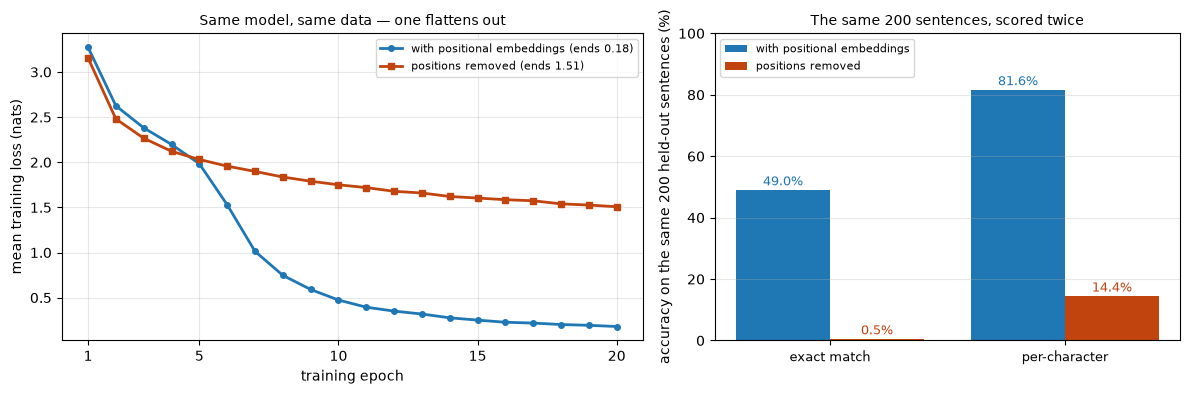


                            exact match  per-character   final train loss
with positional emb.             49.0%          81.6%              0.180
positions removed                 0.5%          14.4%              1.507

What the ablated model actually writes (same held-out sentences as above):
  source   : 'i ought to travel'
  no-pos   : 'It haver tought ooul.'
  author   : 'I ought to travel.'
  source   : 'so goodby my dear'
  no-pos   : 'My dooobe arged Mrs.'
  author   : 'So goodby, my dear.'
  source   : 'then came an interruption and a change'
  no-pos   : 'I cannned the aran an the ane anche and '
  author   : 'Then came an interruption and a change.'
  source   : 'it will be giving him so much pleasure'
  no-pos   : 'I will such beve mingh mpouling s h Mrs.'
  author   : 'It will be giving him so much pleasure!'


In [4]:
# WHAT/WHY: prove the positional-embedding claim rather than asserting it.
# NoPosTransformer overrides ONE method — add_pos returns the embeddings
# unchanged — and inherits everything else, so the comparison is honest.
import matplotlib.pyplot as plt


class NoPosTransformer(Seq2SeqTransformer):
    """The same model with position information removed. The single change."""
    def add_pos(self, emb):
        return emb                      # no position signal reaches attention


torch.manual_seed(0)
nopos = NoPosTransformer(V)
opt_np = optim.Adam(nopos.parameters(), lr=3e-3)

loss_hist_nopos = []
for epoch in range(20):
    nopos.train(); el = 0; nb_ = 0
    perm = torch.randperm(len(X_src))
    for i in range(0, len(X_src), 128):
        b = perm[i:i+128]
        logits = nopos(X_src[b], tgt_in[b])
        loss = loss_fn(logits.reshape(-1, V), tgt_out[b].reshape(-1))
        opt_np.zero_grad(); loss.backward(); opt_np.step(); el += loss.item(); nb_ += 1
    loss_hist_nopos.append(el / nb_)
    if (epoch + 1) % 5 == 0:
        print(f'no-positions, epoch {epoch+1}: mean batch loss={el/nb_:.4f}')


def restore_with(m, src_text):
    """Greedy decode with an explicit model — same procedure as restore()."""
    m.eval()
    src = torch.tensor([encode_src(src_text)], dtype=torch.long)
    tgt = torch.tensor([[SOS]], dtype=torch.long)
    for _ in range(MAX_TGT):
        with torch.no_grad():
            logits = m(src, tgt)
        nxt = int(logits[0, -1].argmax())
        if nxt in (EOS, PAD):
            break
        tgt = torch.cat([tgt, torch.tensor([[nxt]])], dim=1)
    return ''.join(i2c.get(i, '') for i in tgt[0, 1:].tolist())


# ── Score the ablated model on THE SAME 200 held-out sentences ────────────
preds_np = [restore_with(nopos, a) for a, _ in sample]
exact_np = sum(p == b for p, (_, b) in zip(preds_np, sample))
char_hits_np = sum(sum(x == y for x, y in zip(p, b)) for p, (_, b) in zip(preds_np, sample))

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0), gridspec_kw={'width_ratios': [1.25, 1]})

# ── Left: the two learning curves ─────────────────────────────────────────
ep = np.arange(1, 21)
axes[0].plot(ep, loss_hist_pos, 'o-', ms=4, lw=2, color='#1f77b4',
             label=f'with positional embeddings (ends {loss_hist_pos[-1]:.2f})')
axes[0].plot(ep, loss_hist_nopos, 's-', ms=4, lw=2, color='#c1440e',
             label=f'positions removed (ends {loss_hist_nopos[-1]:.2f})')
axes[0].set_xlabel('training epoch'); axes[0].set_ylabel('mean training loss (nats)')
axes[0].set_xticks([1, 5, 10, 15, 20])
axes[0].set_title('Same model, same data — one flattens out', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# ── Right: held-out accuracy, both metrics, both models ───────────────────
metrics = ['exact match', 'per-character']
with_pos = [exact / len(sample) * 100, char_hits / char_tot * 100]
no_pos = [exact_np / len(sample) * 100, char_hits_np / char_tot * 100]
x = np.arange(2)
axes[1].bar(x - 0.2, with_pos, width=0.4, color='#1f77b4', label='with positional embeddings')
axes[1].bar(x + 0.2, no_pos, width=0.4, color='#c1440e', label='positions removed')
for xi, (a, b) in enumerate(zip(with_pos, no_pos)):
    axes[1].text(xi - 0.2, a + 1.5, f'{a:.1f}%', ha='center', fontsize=9, color='#1f77b4')
    axes[1].text(xi + 0.2, b + 1.5, f'{b:.1f}%', ha='center', fontsize=9, color='#c1440e')
axes[1].set_xticks(x); axes[1].set_xticklabels(metrics, fontsize=9)
axes[1].set_ylim(0, 100); axes[1].set_ylabel('accuracy on the same 200 held-out sentences (%)')
axes[1].set_title('The same 200 sentences, scored twice', fontsize=10)
axes[1].legend(fontsize=8, loc='upper left'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f'\n{"":<26}{"exact match":>13}{"per-character":>15}{"final train loss":>19}')
print(f'{"with positional emb.":<26}{exact/len(sample):>12.1%}{char_hits/char_tot:>15.1%}'
      f'{loss_hist_pos[-1]:>19.3f}')
print(f'{"positions removed":<26}{exact_np/len(sample):>12.1%}{char_hits_np/char_tot:>15.1%}'
      f'{loss_hist_nopos[-1]:>19.3f}')

print('\nWhat the ablated model actually writes (same held-out sentences as above):')
for (a, g), p in list(zip(sample, preds_np))[:4]:
    print(f'  source   : {a!r}')
    print(f'  no-pos   : {p!r}')
    print(f'  author   : {g!r}')


**Read the figure.** One change — `add_pos` returns its input untouched — and everything else in
the two runs is identical.

**Left — the loss curves are the same model for four epochs, then they are not.** Up to about
epoch 4 the two are indistinguishable (the ablated run is even marginally *ahead*): both are
learning the easy, order-free part of the task, which is "output letters that look like English".
From epoch 5 the blue curve falls away to **0.18** while the orange one bends over and flattens at
**1.51**. Orange is not training more slowly — look at epochs 15 to 20, where it has essentially
stopped moving. It has run out of things it is capable of learning, and more gradient steps will
not buy any.

**Right — the same 200 held-out sentences, scored twice.** Exact match goes from **49.0%** to
**0.5%** — one sentence out of two hundred. Per-character goes from **81.6%** to **14.4%**.

**Read the printed samples underneath; they are the actual explanation.** Given
`then came an interruption and a change` the ablated model writes
`I cannned the aran an the ane anche and ` — roughly the right letters, roughly the right length,
in the wrong order. That is exactly what a permutation-invariant model can learn: the *bag* of
characters the input suggests, with no way to line input position *i* up with output position *i*.

**One honest correction to the strong version of the claim.** Position information is not *entirely*
gone: the decoder's causal mask still stops each output step from seeing anything after it, which
leaks a weak "how far into the sentence am I" signal — and you can see that surviving in the samples,
which still tend to open with a capital and close with a mark. What the model has lost is alignment
to the *input*. That is why per-character accuracy lands at 14.4% rather than at zero, and it is the
difference between "attention knows roughly where it is in its own output" and "attention can copy
the third character of the source to the third character of the target".

## 💬 Discuss

1. The model scored **49.0% exact match** and **81.6% per-character**. Which number goes in a proposal to a subtitling client, and which one will the client actually *feel* when they read the output? Justify putting either in a contract.
2. The model wrote `It will be giving him so much pleasure.` where Austen wrote `...pleasure!`. Is that an error? Write a definition of "correct" for this task, then say whether your definition is measurable at scale.
3. Whisper made this component largely redundant. What would have to be true about a client's pipeline in 2026 for you to still build it? (Consider languages, on-device constraints, and existing recognisers you cannot replace.)


## 🌍 Related Worked Example — Decoder-Only Generation

The system above is an **encoder–decoder**: a real sentence, stripped, goes in; the restored sentence comes out. The other dominant design is **decoder-only** (GPT): no separate input encoder — the "input" is simply the start of the sequence and the model continues it. For contrast, revisit the decoder-only char-level generator in **example 01**, which is trained on real Usenet posts and real 911 dispatch text. The references below cover both designs.

**Where each one fits:** encoder–decoder wins when input and output are different strings that must stay aligned (translation, summarisation, the truecasing task above). Decoder-only wins when the output is simply a continuation of the input (chat, completion).


## ⚠️ Where this breaks

**Part of this task is irreducibly ambiguous.** Nothing in the stripped string `it will be giving him so much pleasure` says whether the author wrote `.` or `!`. Exact-match therefore has a ceiling below 100% that no model and no volume of data removes. Report per-character accuracy beside it, or you are measuring the ambiguity and calling it model quality.

**Greedy decoding cannot repair itself.** One path, no backtracking: a wrong character early is a wrong sentence. Beam search recovers some of that at a compute cost — worth it when the output is read by a person, wasteful when it is consumed by another model.

**Character-level attention is quadratic in sequence length.** This works on 40-character sentences and stops being the right tool on paragraphs. Subword tokenization is the standard fix, and it is why T5 and BART are subword models.

**Check upstream before you build.** If the client's recogniser already emits punctuation (Whisper-class), this component is dead weight. The most valuable thing an engineer does on a task like this is establish that it is still a task.


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

The encoder–decoder you just trained is still the generator inside modern text-out systems; what moved is where its input comes from. Retrieval-augmented generation introduced exactly this pairing — in the authors' words, "the parametric memory is a pre-trained seq2seq model and the non-parametric memory is a dense vector index of Wikipedia, accessed with a pre-trained neural retriever" — and reported more specific, diverse and factual language than the same seq2seq model on its own (Lewis, P., et al., 2020). In 2026 that arrangement, rather than a task-specific model trained from scratch, is the ordinary way a text-to-text system gets facts nobody trained into it. The 2026 caution is that adding retrieval structure is not automatically an improvement: on three multi-hop question-answering benchmarks fed by synthesized speech, entity-graph linking and iterative reformulation **amplified** upstream recognition errors — the clean-to-noisy F1 gap was 36–67% larger under their combination than under naive dense retrieval, and corrupted query entities accounted for 87–96% of the degradation cases on one of the benchmarks (Bao, 2026). Read that beside your own setting: truecasing is a stage in precisely such a speech pipeline, so every character this component gets wrong is an error a downstream retriever may magnify rather than absorb. Keep building this — the encoder, the causal mask, the positional signal and the greedy decode are the mechanism all of those systems run inside, the ablation you ran is how an engineer proves a component is load-bearing, and it is what the official plan examines.

**Read:** Lewis, P., *et al.* (2020), <https://arxiv.org/abs/2005.11401> · Bao (2026), <https://arxiv.org/abs/2608.22872> (both added to the references below).

## 📚 References & Further Reading

**Papers:**
- Vaswani et al. (2017) — [Attention Is All You Need](https://arxiv.org/abs/1706.03762) *(the Transformer; §3.5 explains positional encodings)*
- Raffel et al. (2020) — [T5: Exploring the Limits of Transfer Learning](https://arxiv.org/abs/1910.10683) *(text-to-text framing)*
- Lewis et al. (2020) — [BART](https://arxiv.org/abs/1910.13461)
- Lewis, P. et al. (2020) — [Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](https://arxiv.org/abs/2005.11401) *(a pretrained seq2seq generator of exactly this family, conditioned on passages fetched from a dense vector index — first author Patrick Lewis, not the Mike Lewis of BART above)*
- Edge et al. (2024) — [From Local to Global: A Graph RAG Approach to Query-Focused Summarization](https://arxiv.org/abs/2404.16130) *(the questions flat retrieval cannot answer — its authors' example is "What are the main themes in the dataset?" — answered instead from an LLM-built entity graph plus pregenerated community summaries)*
- Bao (2026) — [Better Retrieval, Worse Robustness: How Multi-hop RAG Amplifies Upstream ASR Errors](https://arxiv.org/abs/2608.22872) *(what a downstream retriever does with the mistakes a speech-recognition stage like this one leaves behind)*

**Docs:** [`nn.Transformer`](https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html)


## 📝 Summary

In **04 — Building a Text-to-Text Generation System** you built an encoder–decoder Transformer with SOS/EOS handling, teacher forcing, a causal target mask, **learned positional embeddings**, and greedy decoding — then evaluated it on **held-out real sentences** from published books, at a real production task (truecasing and punctuation restoration, the last stage of a speech-recognition pipeline).

Two things to take away:
1. **Positional embeddings are load-bearing — and you measured it.** Retraining the identical model with `add_pos` disabled dropped exact match from **49.0% to 0.5%** and per-character accuracy from **81.6% to 14.4%**, and its training loss flattened at 1.51 instead of reaching 0.18. Without order information, attention cannot align input position to output position, so "capitalise the first letter" and "punctuate the last" stop being expressible.
2. **Read the accuracy honestly.** The model scored **49.0% exact match** but **81.6% per-character** on 200 unseen real sentences. That gap is the finding: it reconstructs most of every sentence and then loses the whole point on one mark. And the misses are largely irreducible — it wrote `It will be giving him so much pleasure.` where Austen wrote `...pleasure!`, and `So goodby My dear.` where Carroll wrote `So goodby, my dear.` Nothing in the stripped input carries that information. A synthetic task engineered to be perfectly solvable (a 100% score on reversing invented digit strings) would have hidden this entire lesson about **irreducible ambiguity in real data**.

T5 and BART are this same architecture at scale, trained on this same "text in → text out" framing.
